---

<a id="import libraries"></a>
## 1 Import Lib

In [11]:


import numpy as np
from roboticstoolbox.robot.ERobot import ERobot, ERobot2
from roboticstoolbox.robot.Robot import Robot
from matplotlib import pyplot
from roboticstoolbox import DHRobot, RevoluteDH, RevoluteMDH
import roboticstoolbox as rtb
from spatialmath import SE3
import os

---

<a id="robot-definition"></a>
## 2 Robot Class Definition

Define a custom robot class that loads the URDF model and provides kinematic capabilities.

In [12]:
class MyRobot(Robot):
    def __init__(self):
        current_dir = os.getcwd()
        urdf_path = os.path.join(current_dir, "src/robot_description/urdf/my-robot.xacro")
        
        links, name, urdf_string, urdf_filepath = ERobot.URDF_read(urdf_path)
        # for link in links:
        #     print(link)

        super().__init__(
            links,
            name=name.upper(),
            manufacturer="RRR Robotics",
            urdf_string=urdf_string,
            urdf_filepath=urdf_filepath,
        )

        self.qz = np.zeros(6)

        self.addconfiguration("qz", self.qz)


---

<a id="forward-kinematics"></a>
## 3 Forward Kinematics Analysis

### 3.1 Robot Initialization and Zero Configuration

ROBOT INFORMATION
ERobot: ROBOT (by RRR Robotics), 3 joints (RRR), geometry
┌──────┬───────────────┬───────┬────────┬───────────────────────────────────────────┐
│ link │     link      │ joint │ parent │            ETS: parent to link            │
├──────┼───────────────┼───────┼────────┼───────────────────────────────────────────┤
│    0 │ link_0        │       │ BASE   │ SE3()                                     │
│    1 │ link_1        │     0 │ link_0 │ SE3(0, 0, 0.2) ⊕ Rz(q0)                   │
│    2 │ link_2        │     1 │ link_1 │ SE3(0, -0.12, 0; 0°, -90°, -90°) ⊕ Rz(q1) │
│    3 │ link_3        │     2 │ link_2 │ SE3(0.25, 0, 0.1) ⊕ Rz(q2)                │
│    4 │ @end_effector │       │ link_3 │ SE3(0.28, 0, 0; 90°, -0°, 90°)            │
└──────┴───────────────┴───────┴────────┴───────────────────────────────────────────┘

┌──────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2  │
├──────┼─────┼─────┼─────┤
│   qz │  0° │  0° │  0° │
└──────┴─────┴─────┴─────┘


ELEMENTARY T

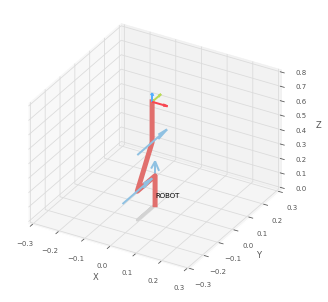

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 432x288 with 0 Axes>

In [13]:
# Initialize robot and display properties
robot = MyRobot()

print("=" * 60)
print("ROBOT INFORMATION")
print("=" * 60)
print(robot)
print("\n" + "=" * 60)
print("ELEMENTARY TRANSFORM SEQUENCE")
print("=" * 60)
print(robot.ets())

print("\n" + "=" * 60)
print("FORWARD KINEMATICS AT ZERO CONFIGURATION")
print("=" * 60)
print(robot.fkine(robot.qz))

# Visualize robot at zero configuration
robot.plot([0,0,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

### 3.2 Testing Joint Movement

Move joint 3 to -90° and visualize the configuration.

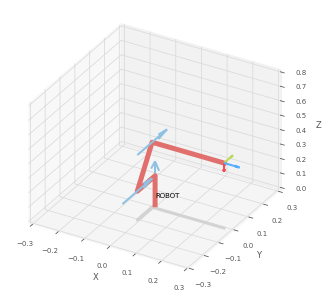

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 432x288 with 0 Axes>

In [14]:
# Configure robot: joint 3 at 90 degrees
robot.qz = [0, 0, np.pi/2]

# Visualize the new configuration
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

### 3.3 Position Error Analysis

Calculate and display the position error between current and target positions.

In [15]:
# Get current end-effector position
T = robot.fkine(robot.qz)
current_pos = T.t

# Define target position
target_pos = np.array([0.2, 0.3, 0.5])

# Compute position error
error = target_pos - current_pos
error_norm = np.linalg.norm(error)

# Display results
print("=" * 60)
print("POSITION ERROR ANALYSIS")
print("=" * 60)
print(f"Current Position:  {current_pos}")
print(f"Target Position:   {target_pos}")
print(f"Position Error:    {error}")
print(f"Error Magnitude:   {error_norm:.6f} m")
print("=" * 60)

POSITION ERROR ANALYSIS
Current Position:  [ 0.27999987 -0.01999996  0.45000013]
Target Position:   [0.2 0.3 0.5]
Position Error:    [-0.07999987  0.31999996  0.04999987]
Error Magnitude:   0.333616 m


---

<a id="motion-control"></a>
## 4 Inverse Kinematics & Velocity Control

### 4.1 Jacobian-based Motion Control

Using resolved-rate motion control with the Jacobian to reach the target position.

STARTING MOTION CONTROL
✓ Target reached at iteration 241!


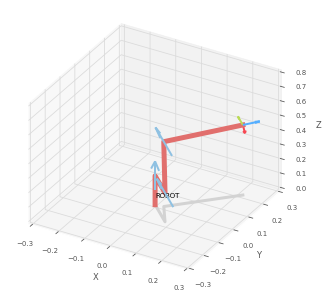

MOTION CONTROL RESULTS
Simulation Time:   2.410 s
Total Iterations:  241
Final Position:    [0.22368854 0.20434765 0.4850442 ]
Target Position:   [0.2 0.3 0.5]
Final Error:       0.099670 m


<Figure size 432x288 with 0 Axes>

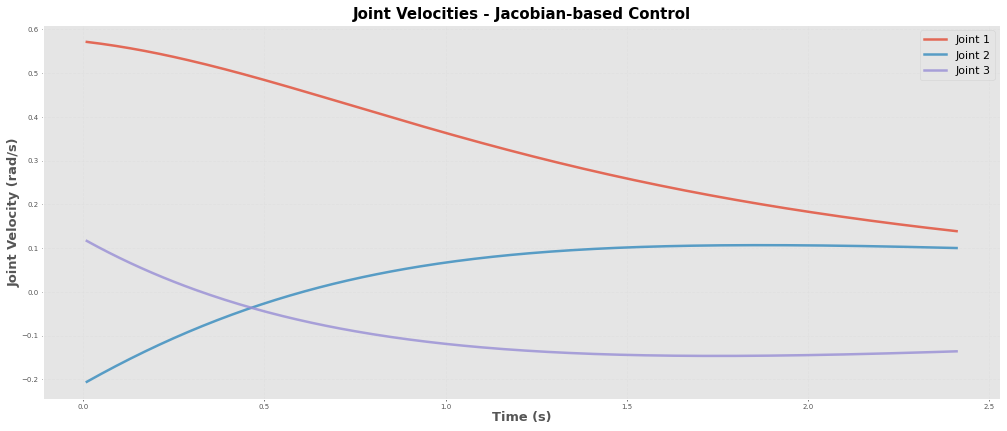

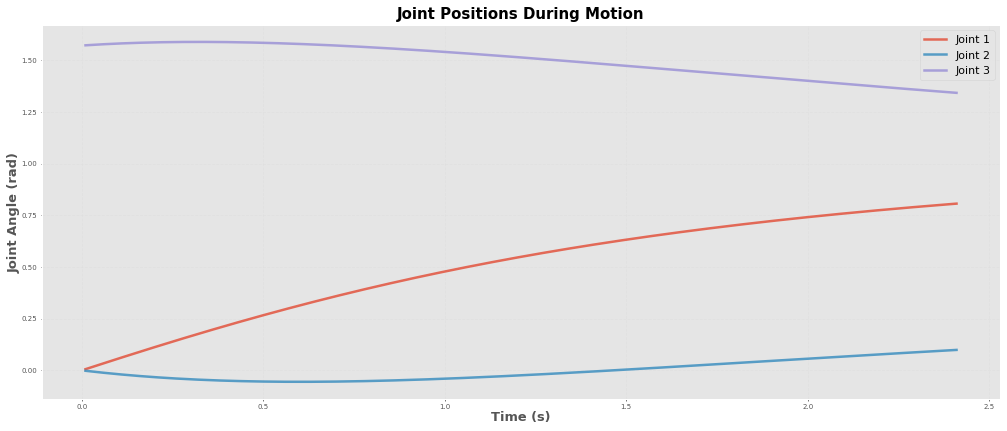

In [16]:
import matplotlib.pyplot as plt

# ========================================
# SIMULATION PARAMETERS
# ========================================
dt = 0.01                    # Time step (s)
max_iterations = 10000       # Safety limit
threshold = 0.1              # Position error threshold (m)
Kp = 0.5                     # Proportional gain

# ========================================
# INITIALIZE TRACKING VARIABLES
# ========================================
arrived = False
computed_joint_velocities = []
joint_positions = []
time_stamps = []
cumulative_time = 0.0
iteration = 0

print("=" * 60)
print("STARTING MOTION CONTROL")
print("=" * 60)

# ========================================
# CONTROL LOOP
# ========================================
while not arrived and iteration < max_iterations:
    # Get current end-effector position
    T = robot.fkine(robot.qz)
    current_pos = T.t
    
    # Compute position error
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)
    
    # Check if arrived
    if error_norm < threshold:
        arrived = True
        print(f"✓ Target reached at iteration {iteration}!")
        break
    
    # Proportional velocity control
    v = Kp * error
    
    # Compute Jacobian
    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]  # Position part only
    
    # Check conditioning
    condJ = np.linalg.cond(J_pos)
    if condJ > 1e12:
        print(f"⚠ Warning: Ill-conditioned Jacobian (cond={condJ:.2e}) at iteration {iteration}")
        break
    
    # Compute joint velocities using pseudo-inverse
    qd = np.linalg.pinv(J_pos) @ v
    
    # Update joint angles
    robot.qz = robot.qz + qd * dt
    
    # Store data for analysis
    computed_joint_velocities.append(qd)
    joint_positions.append(robot.qz.copy())
    cumulative_time += dt
    time_stamps.append(cumulative_time)
    
    iteration += 1

if iteration >= max_iterations and not arrived:
    print("⚠ Maximum iterations reached without convergence")

# ========================================
# CONVERT TO NUMPY ARRAYS
# ========================================
computed_joint_velocities = np.array(computed_joint_velocities) if computed_joint_velocities else np.zeros((0, robot.n))
joint_positions = np.array(joint_positions) if joint_positions else np.zeros((0, robot.n))

# ========================================
# DISPLAY RESULTS
# ========================================
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

print("=" * 60)
print("MOTION CONTROL RESULTS")
print("=" * 60)
print(f"Simulation Time:   {cumulative_time:.3f} s")
print(f"Total Iterations:  {len(time_stamps)}")
print(f"Final Position:    {robot.fkine(robot.qz).t}")
print(f"Target Position:   {target_pos}")
print(f"Final Error:       {np.linalg.norm(target_pos - robot.fkine(robot.qz).t):.6f} m")
print("=" * 60)

# ========================================
# PLOT: JOINT VELOCITIES
# ========================================
plt.figure(figsize=(14, 6))
if len(time_stamps) and computed_joint_velocities.size:
    num_joints = computed_joint_velocities.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, computed_joint_velocities[:, j], 
                label=f'Joint {j+1}', linewidth=2.5, alpha=0.8)
else:
    plt.text(0.5, 0.5, 'No joint velocity data recorded', 
            ha='center', va='center', fontsize=14)

plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Joint Velocity (rad/s)", fontsize=13, fontweight='bold')
plt.title("Joint Velocities - Jacobian-based Control", fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# ========================================
# PLOT: JOINT POSITIONS
# ========================================
plt.figure(figsize=(14, 6))
if len(time_stamps) and joint_positions.size:
    num_joints = joint_positions.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, joint_positions[:, j], 
                label=f'Joint {j+1}', linewidth=2.5, alpha=0.8)
else:
    plt.text(0.5, 0.5, 'No joint position data recorded', 
            ha='center', va='center', fontsize=14)

plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Joint Angle (rad)", fontsize=13, fontweight='bold')
plt.title("Joint Positions During Motion", fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

---

<a id="workspace"></a>
## 5 Workspace Visualization

### 5.1 Monte Carlo Workspace Sampling

Randomly sample joint configurations to visualize the robot's reachable workspace.

JOINT LIMITS (radians)
Lower bounds: [-3.14159 -3.14159 -3.14159]
Upper bounds: [3.14159 3.14159 3.14159]
✓ Generated 2000 workspace samples via Monte Carlo
✓ Generated 2000 workspace samples via Monte Carlo


/tmp/ipykernel_98707/446288315.py:50: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(scatter, ax=ax, label='Z Height (m)', shrink=0.6)


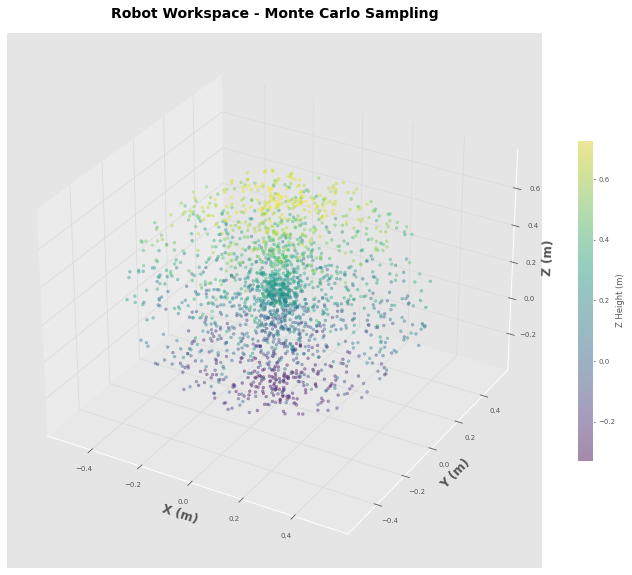

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ========================================
# WORKSPACE SAMPLING PARAMETERS
# ========================================
workspace_samples = 2000

# Get joint limits
qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
lower = qlim[:, 0]
upper = qlim[:, 1]

print("=" * 60)
print("JOINT LIMITS (radians)")
print("=" * 60)
print(f"Lower bounds: {qlim.T[0]}")
print(f"Upper bounds: {qlim.T[1]}")
print("=" * 60)

# ========================================
# GENERATE RANDOM CONFIGURATIONS
# ========================================
workspace_positions = []
for _ in range(workspace_samples):
    rand = np.random.uniform(size=robot.n)
    q_random = lower + rand * (upper - lower)
    T = robot.fkine(q_random)
    workspace_positions.append(np.array(T.t).reshape(-1))

workspace_positions = np.array(workspace_positions)
print(f"✓ Generated {len(workspace_positions)} workspace samples via Monte Carlo")

# ========================================
# VISUALIZE WORKSPACE
# ========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if len(workspace_positions):
    scatter = ax.scatter(workspace_positions[:, 0], 
                        workspace_positions[:, 1], 
                        workspace_positions[:, 2], 
                        c=workspace_positions[:, 2],  # Color by Z height
                        cmap='viridis',
                        s=8, 
                        alpha=0.4)
    fig.colorbar(scatter, ax=ax, label='Z Height (m)', shrink=0.6)

ax.set_xlabel('X (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (m)', fontsize=12, fontweight='bold')
ax.set_zlabel('Z (m)', fontsize=12, fontweight='bold')
ax.set_title('Robot Workspace - Monte Carlo Sampling', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Analytical Workspace (Spherical Shell)

Theoretical workspace based on robot link lengths - represented as a spherical shell.

SPHERICAL SHELL WORKSPACE PARAMETERS
Maximum Radius (r_max): 0.650 m
Minimum Radius (r_min): 0.100 m
Vertical Offset (l):    0.200 m


/tmp/ipykernel_98707/3595493406.py:43: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(scatter, ax=ax, label='Radius (m)', shrink=0.6)


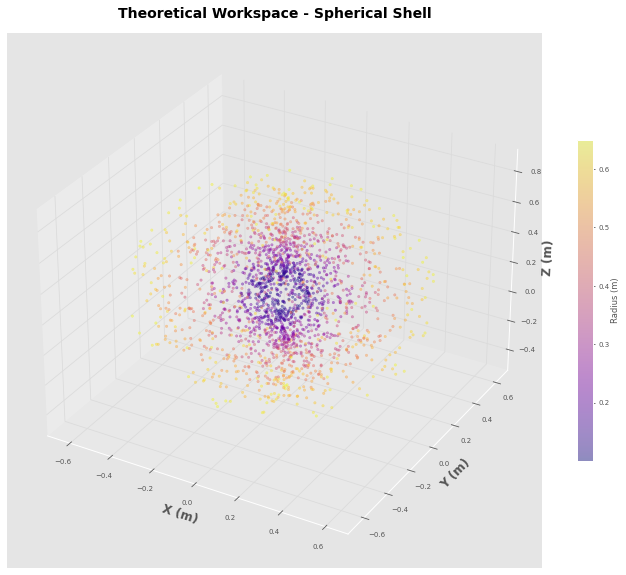

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================
# WORKSPACE PARAMETERS
# ========================================
r_max = 0.12 + 0.25 + 0.28  # Maximum reach (sum of link lengths)
r_min = 0.10                 # Minimum reach
l = 0.2                      # Vertical offset

print("=" * 60)
print("SPHERICAL SHELL WORKSPACE PARAMETERS")
print("=" * 60)
print(f"Maximum Radius (r_max): {r_max:.3f} m")
print(f"Minimum Radius (r_min): {r_min:.3f} m")
print(f"Vertical Offset (l):    {l:.3f} m")
print("=" * 60)

# ========================================
# GENERATE SPHERICAL SHELL POINTS
# ========================================
num_points = 2000
phi = np.random.uniform(0, 2*np.pi, num_points)      # Azimuthal angle
theta = np.random.uniform(0, np.pi, num_points)      # Polar angle
r = np.random.uniform(r_min, r_max, num_points)      # Radius

# Spherical to Cartesian conversion
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = l + r * np.cos(theta)

# ========================================
# VISUALIZE SPHERICAL SHELL
# ========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, 
                    c=r,  # Color by radius
                    cmap='plasma',
                    s=6, 
                    alpha=0.4)
fig.colorbar(scatter, ax=ax, label='Radius (m)', shrink=0.6)

ax.set_xlabel('X (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (m)', fontsize=12, fontweight='bold')
ax.set_zlabel('Z (m)', fontsize=12, fontweight='bold')
ax.set_title('Theoretical Workspace - Spherical Shell', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

<a id="advanced-motion"></a>
## 6 Advanced Motion Planning

### 6.1 Random Pose Generation

Generate a random valid pose within the workspace with good Jacobian conditioning.

In [19]:
import matplotlib.pyplot as plt

# ========================================
# RANDOM POSE GENERATION PARAMETERS
# ========================================
r_max = 0.12 + 0.25 + 0.28
r_min = 0.10
l = 0.2
cond_threshold = 1e3        # Jacobian condition number threshold
max_attempts = 10

position = None
q_solution = None
attempts = 0

print("=" * 60)
print("SEARCHING FOR VALID RANDOM POSE")
print("=" * 60)

# ========================================
# SEARCH FOR VALID POSE
# ========================================
while position is None and attempts < max_attempts:
    # Generate random position in workspace
    x = np.random.uniform(-r_max, r_max)
    y = np.random.uniform(-r_max, r_max)
    z = np.random.uniform(l - r_max, l + r_max)
    size_sq = x**2 + y**2 + (z - l)**2
    
    # Check if within spherical shell
    if not (r_min**2 < size_sq < r_max**2):
        attempts += 1
        continue
    
    # Solve inverse kinematics
    T_target = SE3(x, y, z) @ SE3.Rx(np.pi/2)
    sol = robot.ikine_LM(T_target, mask=[1, 1, 1, 0, 0, 0])
    
    # Check Jacobian conditioning
    q_candidate = sol.q
    J = robot.jacob0(q_candidate)
    condJ = np.linalg.cond(J[:3, :])
    
    if condJ >= cond_threshold:
        print(f"  Attempt {attempts+1}: Rejected (cond = {condJ:.2e})")
        attempts += 1
        continue
    
    # Valid pose found
    position = np.array([x, y, z])
    q_solution = q_candidate
    print(f"  ✓ Valid pose found at attempt {attempts+1}")
    break

# ========================================
# DISPLAY RESULTS
# ========================================
if position is None:
    print(f"\n⚠ Failed to find valid pose within {max_attempts} attempts")
else:
    radius = np.linalg.norm(position - np.array([0, 0, l]))
    print("\n" + "=" * 60)
    print("RANDOM POSE DETAILS")
    print("=" * 60)
    print(f"Position (x,y,z):      {position}")
    print(f"Radius from origin:    {radius:.3f} m")
    print(f"Z-coordinate:          {position[2]:.3f} m")
    print(f"Jacobian condition:    {np.linalg.cond(robot.jacob0(q_solution)[:3, :]):.2e}")
    print(f"Joint configuration:   {q_solution}")
    print("=" * 60)
    
    # Set as target for next section
    target_pos = position.copy()

SEARCHING FOR VALID RANDOM POSE
  ✓ Valid pose found at attempt 2

RANDOM POSE DETAILS
Position (x,y,z):      [-0.14972044  0.44436142 -0.12636547]
Radius from origin:    0.571 m
Z-coordinate:          -0.126 m
Jacobian condition:    2.45e+01
Joint configuration:   [-4.34313042 -4.21301846  0.20871272]
  ✓ Valid pose found at attempt 2

RANDOM POSE DETAILS
Position (x,y,z):      [-0.14972044  0.44436142 -0.12636547]
Radius from origin:    0.571 m
Z-coordinate:          -0.126 m
Jacobian condition:    2.45e+01
Joint configuration:   [-4.34313042 -4.21301846  0.20871272]


### 6.2 Motion to Random Pose

Execute motion control to reach the randomly generated target pose.

MOTION TO RANDOM POSE
Starting Position: [0.22368854 0.20434765 0.4850442 ]
Target Position:   [-0.14972044  0.44436142 -0.12636547]
Initial Error:     0.755555 m

⚠ Maximum iterations reached


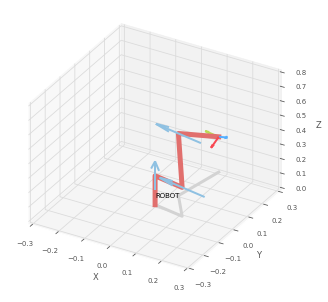


MOTION RESULTS
Simulation Time:   1.000 s
Total Iterations:  100
Final Position:    [0.07589733 0.29794098 0.24403213]
Target Position:   [-0.14972044  0.44436142 -0.12636547]
Final Error:       0.457752 m
RMSE:              0.264283 m


<Figure size 432x288 with 0 Axes>

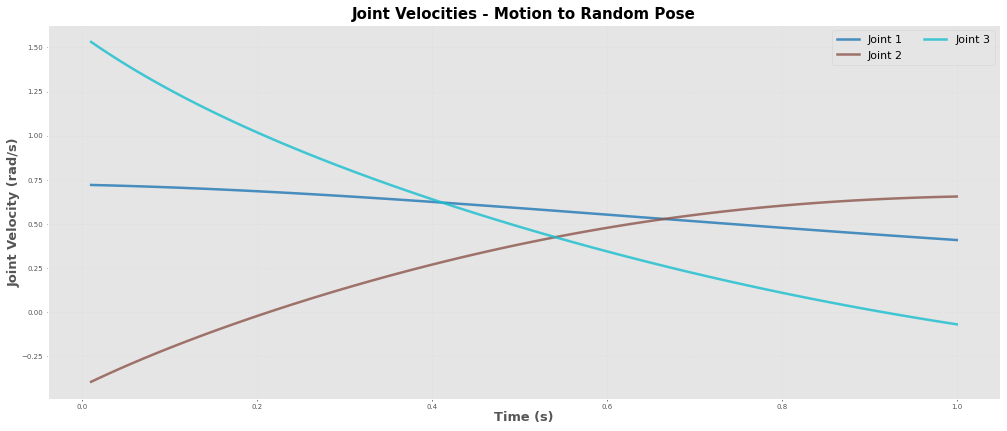

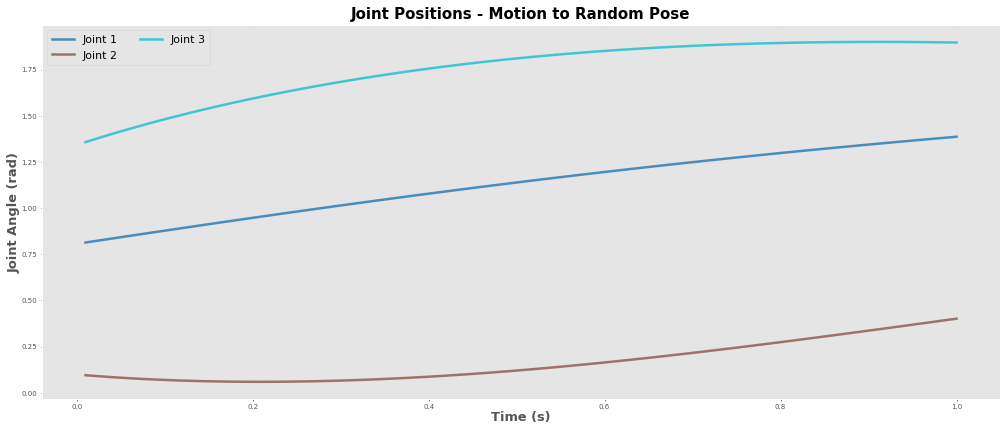

In [20]:
import matplotlib.pyplot as plt

# ========================================
# VALIDATE TARGET
# ========================================
if 'target_pos' not in globals():
    raise RuntimeError('⚠ Please run the random pose generation cell first!')

# ========================================
# SIMULATION PARAMETERS
# ========================================
dt = 0.01                    # Time step (s)
max_iterations = 100         # Maximum iterations
threshold = 0.01             # Convergence threshold (m)
Kp = 0.5                     # Proportional gain

# ========================================
# INITIALIZE TRACKING
# ========================================
arrived = False
computed_joint_velocities = []
joint_positions = []
time_stamps = []
cumulative_time = 0.0
iteration = 0

start_tcp = robot.fkine(robot.qz)
start_config = np.array(start_tcp.t).reshape(-1)

print("=" * 60)
print("MOTION TO RANDOM POSE")
print("=" * 60)
print(f"Starting Position: {start_config}")
print(f"Target Position:   {target_pos}")
print(f"Initial Error:     {np.linalg.norm(target_pos - start_config):.6f} m")
print("=" * 60 + "\n")

# ========================================
# CONTROL LOOP
# ========================================
while not arrived and iteration < max_iterations:
    # Get current position
    T = robot.fkine(robot.qz)
    current_pos = T.t
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)
    
    # Check convergence
    if error_norm < threshold:
        arrived = True
        print(f"✓ Target reached at iteration {iteration}!")
        break
    
    # Compute control velocity
    v = Kp * error
    
    # Get Jacobian
    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]
    condJ = np.linalg.cond(J_pos)
    
    if condJ > 1e12:
        print(f"⚠ Warning: Ill-conditioned Jacobian (cond={condJ:.2e}) at iteration {iteration}")
        break
    
    # Compute joint velocities
    qd = np.linalg.pinv(J_pos) @ v
    robot.qz = robot.qz + qd * dt
    
    # Record data
    computed_joint_velocities.append(qd)
    joint_positions.append(robot.qz.copy())
    cumulative_time += dt
    time_stamps.append(cumulative_time)
    
    iteration += 1

if iteration >= max_iterations and not arrived:
    print("⚠ Maximum iterations reached")

# ========================================
# CONVERT TO ARRAYS
# ========================================
computed_joint_velocities = np.array(computed_joint_velocities) if computed_joint_velocities else np.zeros((0, robot.n))
joint_positions = np.array(joint_positions) if joint_positions else np.zeros((0, robot.n))

# ========================================
# DISPLAY RESULTS
# ========================================
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

final_pos = robot.fkine(robot.qz).t
final_error = np.linalg.norm(target_pos - final_pos)
rmse = np.sqrt(np.mean((target_pos - final_pos)**2))

print("\n" + "=" * 60)
print("MOTION RESULTS")
print("=" * 60)
print(f"Simulation Time:   {cumulative_time:.3f} s")
print(f"Total Iterations:  {len(time_stamps)}")
print(f"Final Position:    {final_pos}")
print(f"Target Position:   {target_pos}")
print(f"Final Error:       {final_error:.6f} m")
print(f"RMSE:              {rmse:.6f} m")
print("=" * 60)

# ========================================
# PLOT: JOINT VELOCITIES
# ========================================
plt.figure(figsize=(14, 6))
if len(time_stamps) and computed_joint_velocities.size:
    num_joints = computed_joint_velocities.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, num_joints))
    for j in range(num_joints):
        plt.plot(time_stamps, computed_joint_velocities[:, j], 
                label=f'Joint {j+1}', linewidth=2.5, alpha=0.8, color=colors[j])
else:
    plt.text(0.5, 0.5, 'No data recorded', ha='center', va='center', fontsize=14)

plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Joint Velocity (rad/s)", fontsize=13, fontweight='bold')
plt.title("Joint Velocities - Motion to Random Pose", fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best', ncol=2)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# ========================================
# PLOT: JOINT POSITIONS
# ========================================
plt.figure(figsize=(14, 6))
if len(time_stamps) and joint_positions.size:
    num_joints = joint_positions.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, num_joints))
    for j in range(num_joints):
        plt.plot(time_stamps, joint_positions[:, j], 
                label=f'Joint {j+1}', linewidth=2.5, alpha=0.8, color=colors[j])
else:
    plt.text(0.5, 0.5, 'No data recorded', ha='center', va='center', fontsize=14)

plt.xlabel("Time (s)", fontsize=13, fontweight='bold')
plt.ylabel("Joint Angle (rad)", fontsize=13, fontweight='bold')
plt.title("Joint Positions - Motion to Random Pose", fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best', ncol=2)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()